In [64]:
from langchain_groq import ChatGroq
import os
from dotenv import load_dotenv
from google.colab import userdata
from langgraph.graph import StateGraph , START , END
from typing import TypedDict
from pydantic import BaseModel
from langgraph.checkpoint.memory import InMemorySaver
import time

api_key = userdata.get("groq_api_key")

model = ChatGroq(
    model="llama-3.1-8b-instant",
    api_key=api_key
)


In [65]:
class fault_state(TypedDict):
  input:str
  step1:str
  step2:str

In [76]:
def step1(state:fault_state):
  print("Step1 is Done........")
  return {"step1":"Done" , input:state["input"]}

def step2(state:fault_state):
  print("Step2 is loading........")
  time.sleep(20)
  print("Step2 is successfully........")
  return {"step2":"Done"}

In [78]:
graph = StateGraph(fault_state)

In [79]:
graph.add_node("step1" , step1)
graph.add_node("step2" , step2)

graph.add_edge(START , "step1")
graph.add_edge("step1" , "step2")
graph.add_edge("step2" , END)

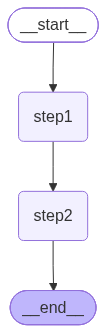

In [88]:
checkpointer = InMemorySaver()
workflow = graph.compile(checkpointer=checkpointer)

In [85]:
config = {
    "configurable":{
        "thread_id":1 ,
    }
    }
try:
  output = workflow.invoke({"input":"Hello"} , config=config)
  print(output)
except KeyboardInterrupt:
  print("keyboard interrupt: corrupt file")

Step1 is Done........
Step2 is loading........
keyboard interrupt: corrupt file


In [91]:
workflow.get_state(config)

StateSnapshot(values={'input': 'Hello', 'step1': 'Done', 'step2': 'Done'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1922f4-9c47-64e5-8002-737e3b75e056'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-08-07T07:12:02.392558+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1922de-4c9f-668a-8001-b6a421080196'}}, tasks=(), interrupts=())

In [87]:
list(workflow.get_state_history(config))

[StateSnapshot(values={'input': 'Hello', 'step1': 'Done'}, next=('step2',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1922de-4c9f-668a-8001-b6a421080196'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-08-07T07:02:03.482047+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1922de-4c98-6e4d-8000-c9b40b764c58'}}, tasks=(PregelTask(id='369c2382-4f19-0299-8166-624cc171f06d', name='step2', path=('__pregel_pull', 'step2'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'input': 'Hello'}, next=('step1',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1922de-4c98-6e4d-8000-c9b40b764c58'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-08-07T07:02:03.479378+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1922de-4c92-6c3

In [89]:
output2 = workflow.invoke(None , config)
print(output2)

Step2 is loading........
Step2 is successfully........


In [92]:
workflow.get_state(config)

StateSnapshot(values={'input': 'Hello', 'step1': 'Done', 'step2': 'Done'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1922f4-9c47-64e5-8002-737e3b75e056'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-08-07T07:12:02.392558+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1922de-4c9f-668a-8001-b6a421080196'}}, tasks=(), interrupts=())

In [93]:
list(workflow.get_state_history(config))

[StateSnapshot(values={'input': 'Hello', 'step1': 'Done', 'step2': 'Done'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1922f4-9c47-64e5-8002-737e3b75e056'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-08-07T07:12:02.392558+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1922de-4c9f-668a-8001-b6a421080196'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'input': 'Hello', 'step1': 'Done'}, next=('step2',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1922de-4c9f-668a-8001-b6a421080196'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-08-07T07:02:03.482047+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1922de-4c98-6e4d-8000-c9b40b764c58'}}, tasks=(PregelTask(id='369c2382-4f19-0299-8166-624cc171f06d', name='step2', path=('__pregel_pull', 'step